## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing Necessary Libraries**

In [3]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install -U sentence-transformers gensim transformers tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 96.7 MB/s eta 0:00:00


In [4]:
# to read and manipulate the data
import pandas as pd
import numpy as np
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# to use regular expressions for manipulating text data
import re

# to manipulate string data
import string

# to load the natural language toolkit
import nltk
nltk.download('stopwords')    # loading the stopwords
nltk.download('wordnet')    # loading the wordnet module that is used in stemming

# to remove common stop words
from nltk.corpus import stopwords

# to perform stemming
from nltk.stem.porter import PorterStemmer

# Importing the SpaCy library
import spacy
nlp = spacy.load('en_core_web_sm')    # loading the envrionment config

# Used in tokenization
from spacy.lang.en import English

# To import Word2Vec
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## **Loading the dataset**

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
stock_news_path = "/content/drive/MyDrive/AI-ML/M05/Main-P/stock_news.csv"
stock_news = pd.read_csv(stock_news_path)

In [14]:
data = stock_news.copy()

## **Data Overview**

In [8]:
data.shape

(349, 8)

In [9]:
data.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


In [10]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,349,71,2019-01-03,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
News,349,349,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Open,349.0,NaN,NaN,NaN,46.229233,6.442817,37.567501,41.740002,45.974998,50.7075,66.817497
High,349.0,NaN,NaN,NaN,46.700458,6.507321,37.817501,42.244999,46.025002,50.849998,67.0625
Low,349.0,NaN,NaN,NaN,45.745394,6.391976,37.305,41.482498,45.639999,49.7775,65.862503
Close,349.0,NaN,NaN,NaN,44.926317,6.398338,36.254131,40.246914,44.596924,49.11079,64.805229
Volume,349.0,NaN,NaN,NaN,128948236.103152,43170314.918964,45448000.0,103272000.0,115627200.0,151125200.0,244439200.0
Label,349.0,NaN,NaN,NaN,-0.054441,0.715119,-1.0,-1.0,0.0,0.0,1.0


The dataset contains 349 records and 8 features, providing sufficient data for analysis and modeling.

There are no missing values in the dataset, ensuring data completeness and reliability.

The dataset contains no duplicate records, confirming that each observation is unique.

The News column has 349 unique entries, indicating that each record is associated with a distinct news article.

The Date column has 71 unique trading days, meaning multiple news articles are available for some days.

The average opening stock price is around 46.23, with values ranging from approximately 37.56 to 66.82.

The closing price averages around 44.93, showing moderate variation during the observed period.

The trading volume averages about 128.9 million shares, indicating high market activity for the stock.

The Label variable ranges from -1 to 1, representing negative, neutral, and positive stock price movements.

The mean label value is slightly negative (-0.054), suggesting a marginally higher occurrence of negative price movements.

## **Exploratory Data Analysis**

### Univariate Analysis

* Distribution of individual variables
* Compute and check the distribution of the length of news content

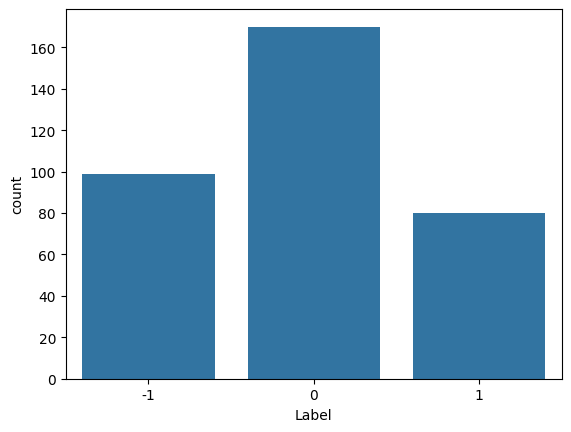

In [13]:
sns.countplot(data=data, x='Label');

['Open', 'High', 'Low', 'Close', 'Volume']


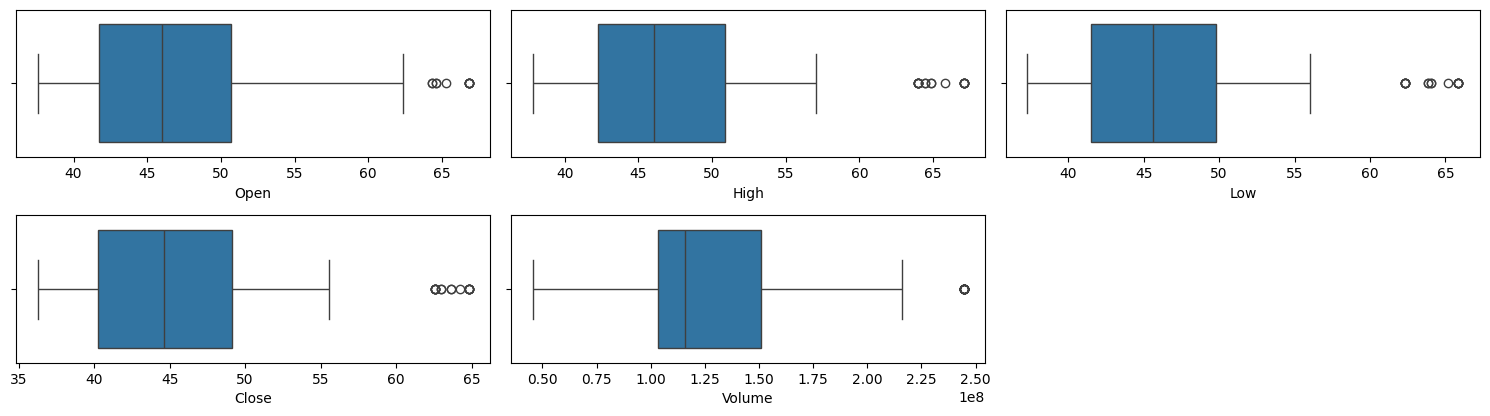

In [14]:
plt.figure(figsize=(15, 10))

features_for_univarent_analysis = ["Open", "High","Low","Close","Volume"]
print(features_for_univarent_analysis)


for i , feature in enumerate(features_for_univarent_analysis):
    plt.subplot(5, 3, i+1)
    sns.boxplot(data=data, x=feature)

    plt.tight_layout();

The Open price shows moderate variability with a few higher-value observations indicating possible price spikes during certain trading days.

The High price distribution is slightly wider than the Open price, suggesting occasional intraday upward movements in stock prices.

The Low price values appear relatively concentrated, indicating that extreme downward movements are less frequent.

The Close price distribution closely follows the Open price pattern, showing that the stock generally closes near its opening level with limited extreme deviations.

The Volume feature exhibits noticeable variability and several high-value outliers, indicating days with unusually high trading activity.

Overall, most price-related features (Open, High, Low, Close) appear fairly stable with limited outliers, suggesting controlled price fluctuations during the observed period.

### Bivariate Analysis

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

<Figure size 1600x1200 with 0 Axes>

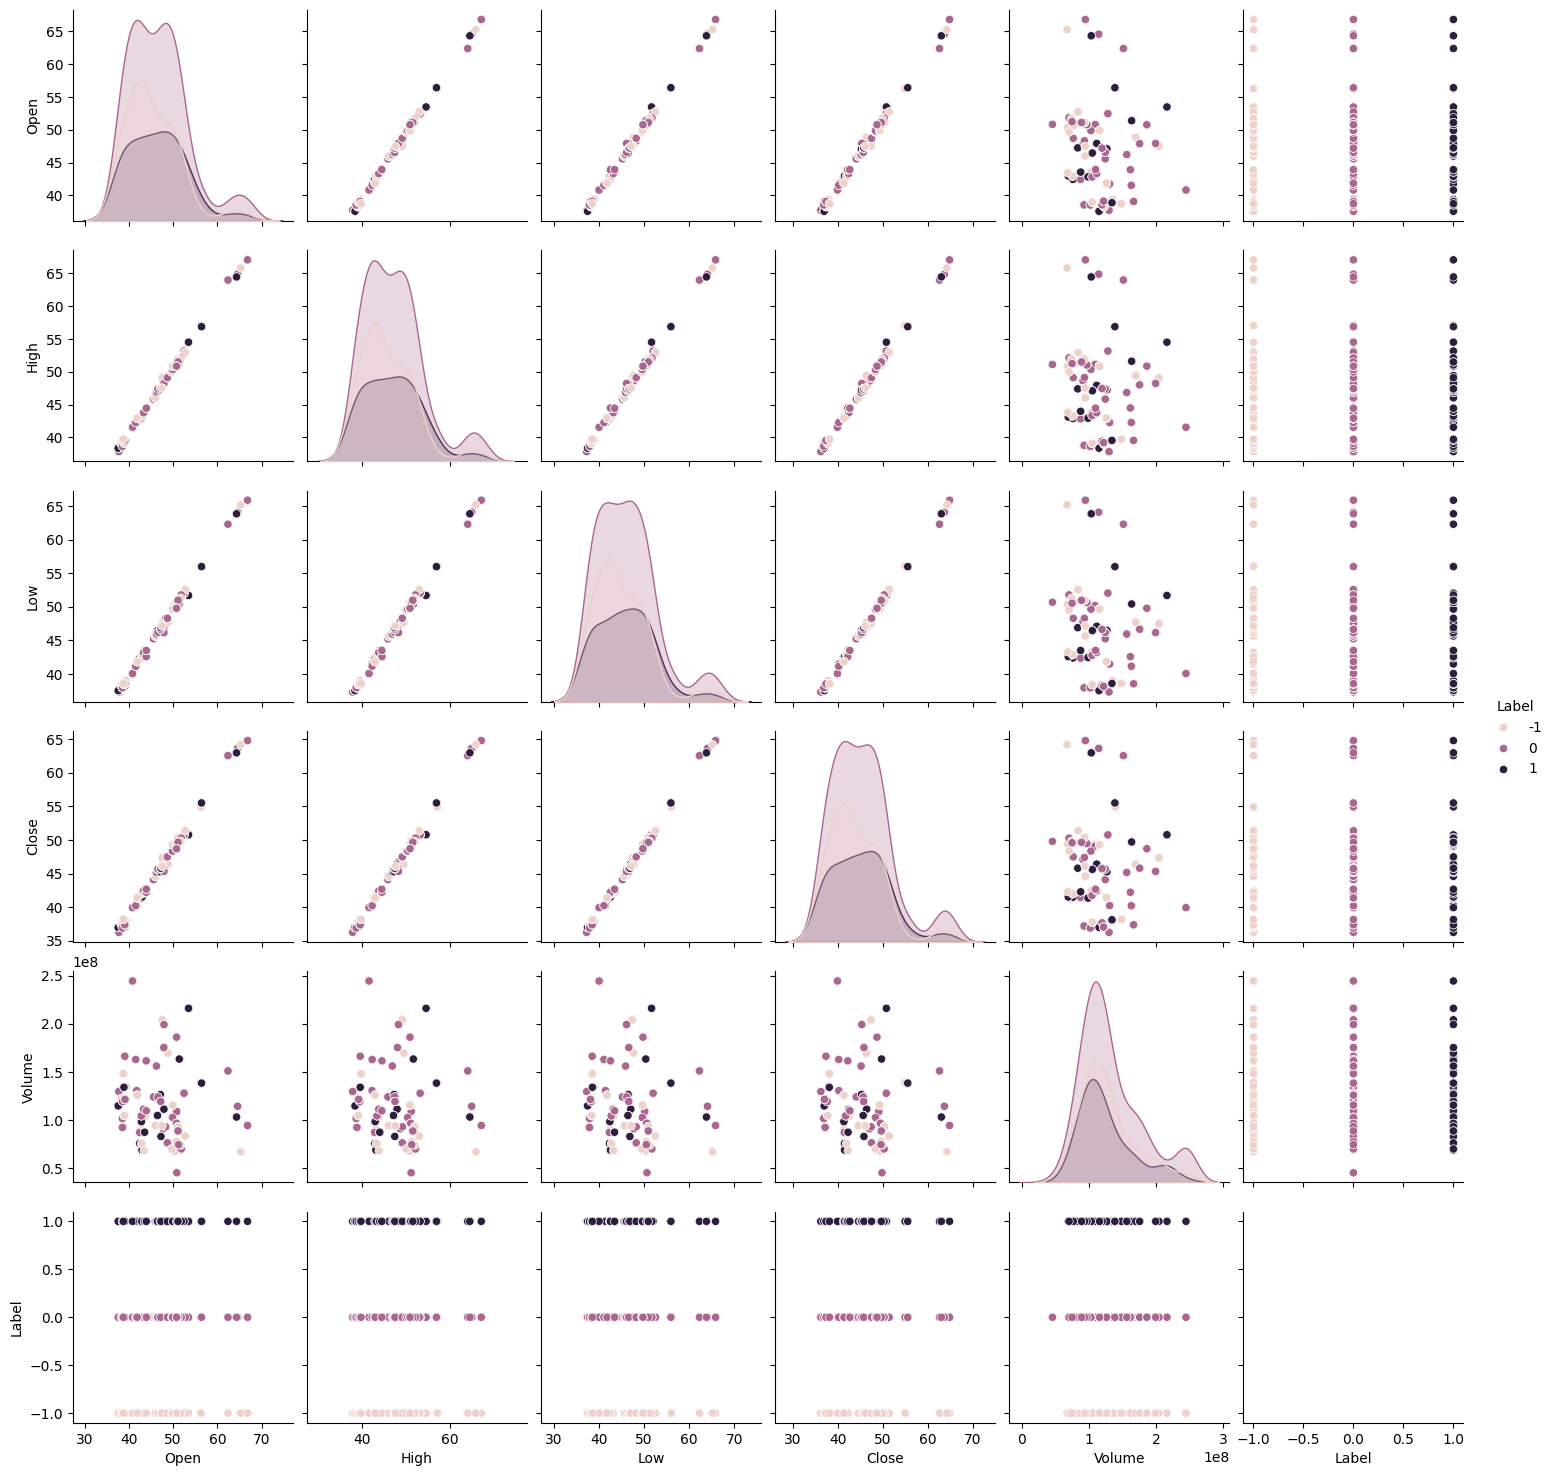

In [15]:
# Scatter plot matrix
plt.figure(figsize=(16, 12))

features_for_bivarent_analysis = ["Open", "High","Low","Close","Volume","Label"]
# plotting the PairPlot for correlation
sns.pairplot(data, vars=features_for_bivarent_analysis, hue='Label', diag_kind='kde');

Open, High, Low, and Close prices show a very strong positive linear relationship, indicating that these price features move closely together.

The High price increases proportionally with the Open and Close prices, suggesting consistent intraday price movements.

The Low price also follows a strong positive correlation with other price variables, showing that price ranges remain relatively stable.

The Close price is highly correlated with Open, High, and Low prices, indicating that closing values largely depend on the day’s trading range.

Trading Volume does not show a strong correlation with the price features, suggesting that higher trading activity does not necessarily correspond to higher or lower prices.

When colored by Label (-1, 0, 1), the data points for different classes overlap significantly, indicating that price features alone may not clearly separate stock movement classes.

The Label distribution appears spread across similar price ranges, implying that stock movement direction may depend more on external factors such as news rather than price levels alone.

Overall, the price-related variables exhibit multicollinearity, which may require dimensionality reduction or feature selection in predictive modeling.

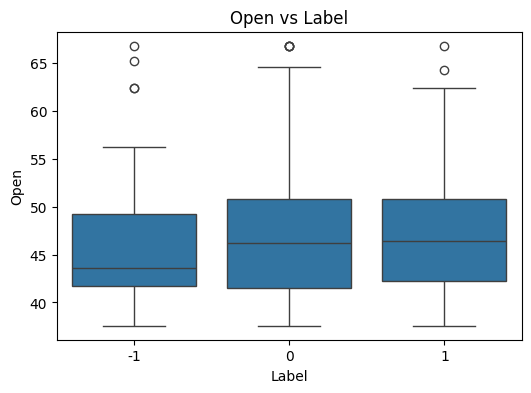

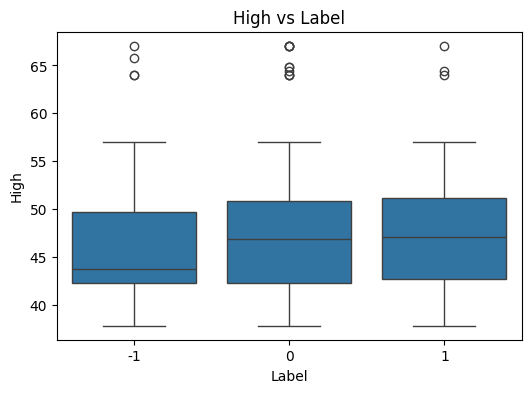

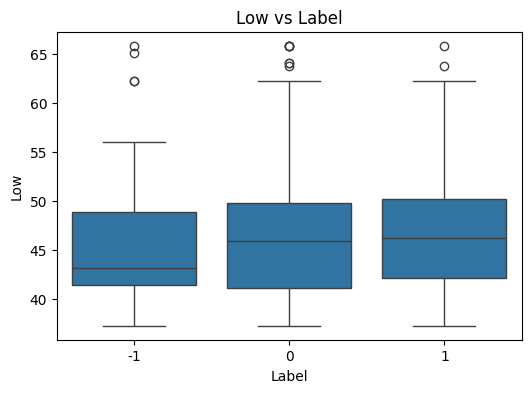

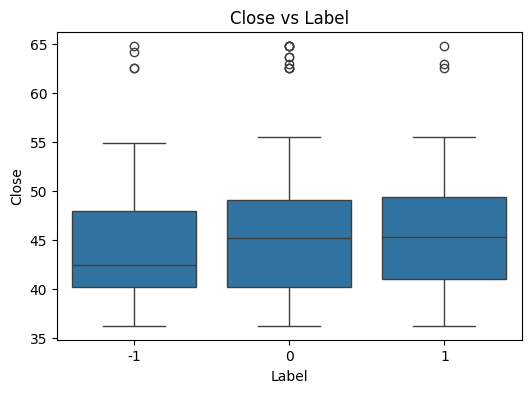

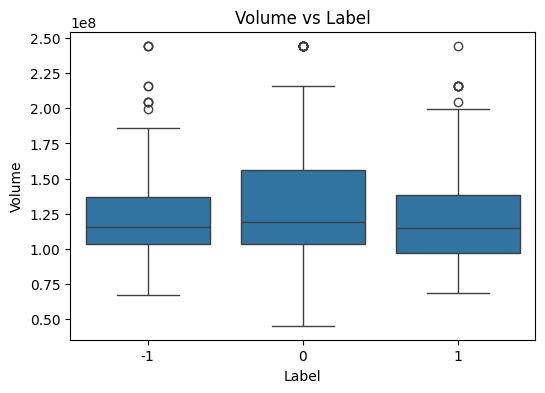

In [16]:
features = ["Open","High","Low","Close","Volume"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data["Label"], y=data[feature])
    plt.title(f"{feature} vs Label")
    plt.show()

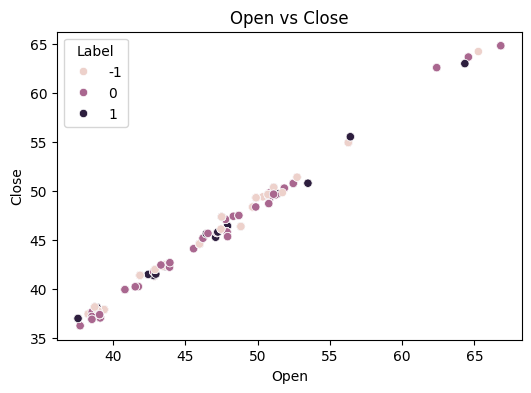

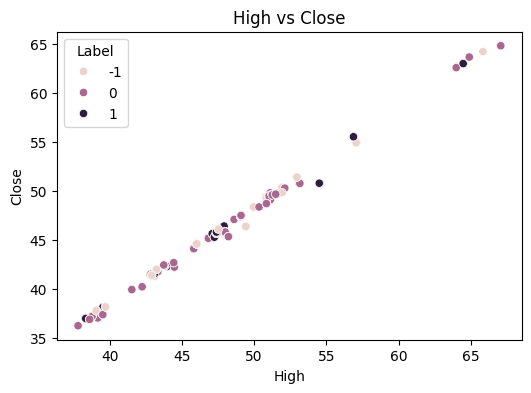

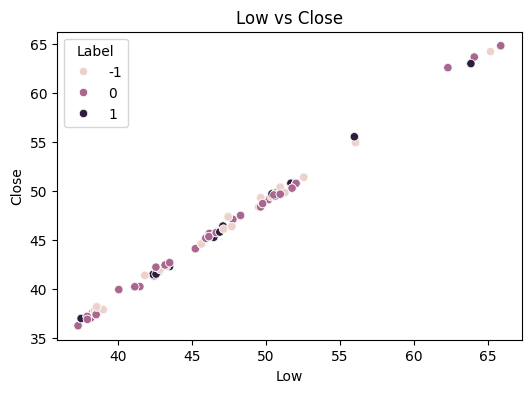

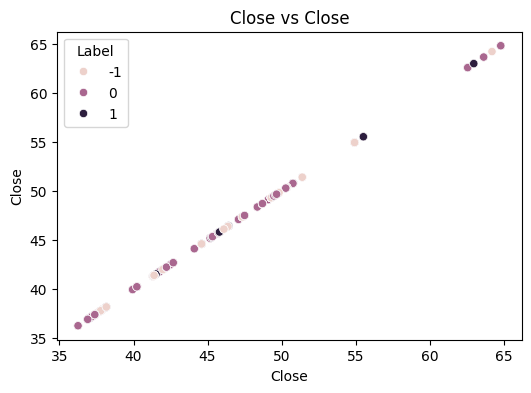

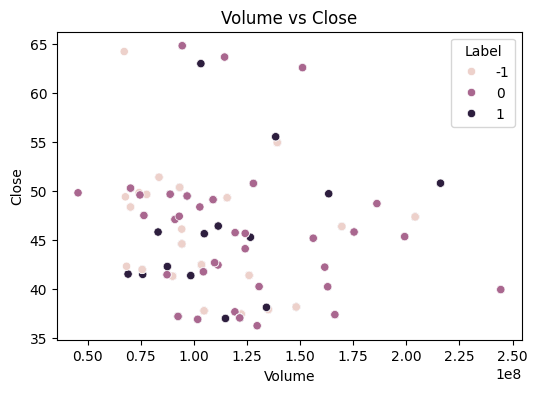

In [17]:
features = ["Open","High","Low","Close","Volume"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=data[feature], y=data["Close"], hue=data["Label"])
    plt.title(f"{feature} vs Close")
    plt.show()

The Open price distribution across different labels (-1, 0, 1) appears largely overlapping, indicating that opening prices alone may not strongly distinguish stock movement classes.

The High price shows similar distributions across all label categories, suggesting that intraday peak prices are not strongly associated with the direction of stock movement.

The Low price also exhibits significant overlap among the three labels, indicating that the minimum price of the day does not clearly separate positive or negative movements.

The Close price distribution is relatively similar across all label groups, implying that closing prices alone may not be sufficient to determine the movement class.

The Volume feature shows higher variability and several outliers across labels, indicating that trading activity fluctuates considerably but does not clearly differentiate stock movement categories.

Overall, the strong overlap between label groups suggests that price-based features alone may not provide strong predictive separation, highlighting the importance of incorporating additional information such as news sentiment.

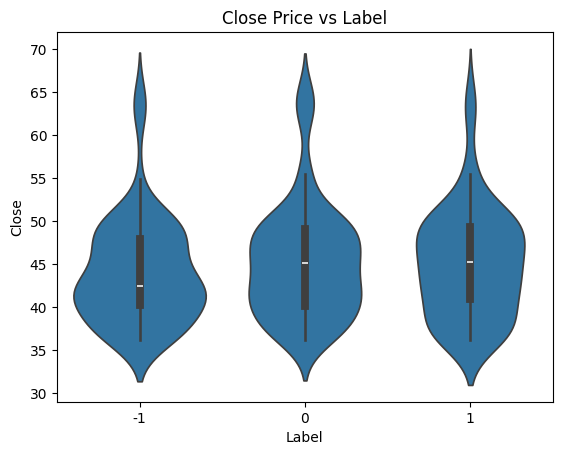

In [18]:
sns.violinplot(x=data["Label"], y=data["Close"])
plt.title("Close Price vs Label")
plt.show()

The distribution of closing prices is broadly similar across all three label categories (-1, 0, 1), indicating no strong separation based on closing price alone.

The median closing price appears slightly higher for Label = 1, suggesting that positive stock movement tends to occur when prices are relatively higher.

The spread of closing prices for Label = -1 and Label = 1 is wider, indicating greater variability in prices during negative and positive movements.

The density of observations is concentrated around the 40–50 price range for all labels, suggesting that most trading activity occurs within this range.

The significant overlap between the distributions of all three labels indicates that closing price alone may not be sufficient to clearly distinguish stock movement categories, highlighting the need for additional features such as news sentiment or other market indicators.

## **Data Preprocessing**

In [19]:
def remove_special_characters(text):
    # Defining the regex pattern to match non-alphanumeric characters
    pattern = '[^A-Za-z0-9]+'

    # Finding the specified pattern and replacing non-alphanumeric characters with a blank string
    new_text = ''.join(re.sub(pattern, ' ', text))

    return new_text

In [20]:
data['cleaned_News'] = data['News'].apply(remove_special_characters)

In [21]:
data.loc[0:3, ['News','cleaned_News']]

,News,cleaned_News
0,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",The tech sector experienced a significant decline in the aftermarket following Apple s Q1 revenue warning Notable suppliers including Skyworks Broadcom Lumentum Qorvo and TSMC saw their stocks drop in response to Apple s downward revision of its revenue expectations for the quarter previously announced in January
1,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",Apple lowered its fiscal Q1 revenue guidance to 84 billion from earlier estimates of 89 93 billion due to weaker than expected iPhone sales The announcement caused a significant drop in Apple s stock price and negatively impacted related suppliers leading to broader market declines for tech indices such as Nasdaq 10
2,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",Apple cut its fiscal first quarter revenue forecast from 89 93 billion to 84 billion due to weaker demand in China and fewer iPhone upgrades CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks Apple s shares fell 8 5 in post market trading while Asian suppliers like Hon
3,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",This news article reports that yields on long dated U S Treasury securities hit their lowest levels in nearly a year on January 2 2019 due to concerns about the health of the global economy following weak economic data from China and Europe as well as the partial U S government shutdown Apple


In [22]:
data['cleaned_News'] = data['cleaned_News'].str.lower()

In [23]:
data['cleaned_News'] = data['cleaned_News'].str.strip()

In [24]:
def remove_stopwords(text):
    # Split text into separate words
    words = text.split()

    # Removing English language stopwords
    new_text = ' '.join([word for word in words if word not in stopwords.words('english')])

    return new_text

In [25]:
data['cleaned_News_without_stopwords'] = data['cleaned_News'].apply(remove_stopwords)

In [26]:
data.loc[0:3,['cleaned_News','cleaned_News_without_stopwords']]

,cleaned_News,cleaned_News_without_stopwords
0,the tech sector experienced a significant decline in the aftermarket following apple s q1 revenue warning notable suppliers including skyworks broadcom lumentum qorvo and tsmc saw their stocks drop in response to apple s downward revision of its revenue expectations for the quarter previously announced in january,tech sector experienced significant decline aftermarket following apple q1 revenue warning notable suppliers including skyworks broadcom lumentum qorvo tsmc saw stocks drop response apple downward revision revenue expectations quarter previously announced january
1,apple lowered its fiscal q1 revenue guidance to 84 billion from earlier estimates of 89 93 billion due to weaker than expected iphone sales the announcement caused a significant drop in apple s stock price and negatively impacted related suppliers leading to broader market declines for tech indices such as nasdaq 10,apple lowered fiscal q1 revenue guidance 84 billion earlier estimates 89 93 billion due weaker expected iphone sales announcement caused significant drop apple stock price negatively impacted related suppliers leading broader market declines tech indices nasdaq 10
2,apple cut its fiscal first quarter revenue forecast from 89 93 billion to 84 billion due to weaker demand in china and fewer iphone upgrades ceo tim cook also mentioned constrained sales of airpods and macbooks apple s shares fell 8 5 in post market trading while asian suppliers like hon,apple cut fiscal first quarter revenue forecast 89 93 billion 84 billion due weaker demand china fewer iphone upgrades ceo tim cook also mentioned constrained sales airpods macbooks apple shares fell 8 5 post market trading asian suppliers like hon
3,this news article reports that yields on long dated u s treasury securities hit their lowest levels in nearly a year on january 2 2019 due to concerns about the health of the global economy following weak economic data from china and europe as well as the partial u s government shutdown apple,news article reports yields long dated u treasury securities hit lowest levels nearly year january 2 2019 due concerns health global economy following weak economic data china europe well partial u government shutdown apple


Stemming

In [27]:
ps = PorterStemmer()

In [28]:
def apply_porter_stemmer(text):
    # Split text into separate words
    words = text.split()

    # Applying the Porter Stemmer on every word of a message and joining the stemmed words back into a single string
    new_text = ' '.join([ps.stem(word) for word in words])

    return new_text

In [29]:
data['final_cleaned_News'] = data['cleaned_News_without_stopwords'].apply(apply_porter_stemmer)

In [30]:
data.loc[0:2,['cleaned_News_without_stopwords','final_cleaned_News']]

,cleaned_News_without_stopwords,final_cleaned_News
0,tech sector experienced significant decline aftermarket following apple q1 revenue warning notable suppliers including skyworks broadcom lumentum qorvo tsmc saw stocks drop response apple downward revision revenue expectations quarter previously announced january,tech sector experienc signific declin aftermarket follow appl q1 revenu warn notabl supplier includ skywork broadcom lumentum qorvo tsmc saw stock drop respons appl downward revis revenu expect quarter previous announc januari
1,apple lowered fiscal q1 revenue guidance 84 billion earlier estimates 89 93 billion due weaker expected iphone sales announcement caused significant drop apple stock price negatively impacted related suppliers leading broader market declines tech indices nasdaq 10,appl lower fiscal q1 revenu guidanc 84 billion earlier estim 89 93 billion due weaker expect iphon sale announc caus signific drop appl stock price neg impact relat supplier lead broader market declin tech indic nasdaq 10
2,apple cut fiscal first quarter revenue forecast 89 93 billion 84 billion due weaker demand china fewer iphone upgrades ceo tim cook also mentioned constrained sales airpods macbooks apple shares fell 8 5 post market trading asian suppliers like hon,appl cut fiscal first quarter revenu forecast 89 93 billion 84 billion due weaker demand china fewer iphon upgrad ceo tim cook also mention constrain sale airpod macbook appl share fell 8 5 post market trade asian supplier like hon


## **Word Embeddings**

###Word2Vec

In [31]:
words_list = [item.split(" ") for item in data['final_cleaned_News'].values]

In [32]:
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [33]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 2580


In [34]:
word = "good"
model_W2V.wv[word]

array([ 2.3296655e-03,  1.9700897e-03,  7.3501084e-04,  2.7708083e-03,
       -1.2059312e-03, -3.4831637e-03,  1.2356940e-03,  2.1669238e-03,
       -1.8245088e-04, -2.3468793e-03, -4.0196092e-04,  1.5803197e-03,
        2.8465528e-03, -2.7383103e-03,  1.3135721e-04, -1.2971179e-03,
        1.3652606e-03, -1.0283447e-03,  3.1393089e-03, -1.5251456e-03,
       -3.9327652e-03, -1.7281733e-03,  1.2052062e-03, -1.4744648e-03,
        8.3329401e-04,  1.0834673e-03, -2.1118154e-03, -6.7251030e-04,
        8.5120631e-04, -4.2671585e-03,  7.3070795e-04, -1.1349431e-03,
        1.6631370e-03, -1.7843771e-03, -2.8077057e-03, -1.5664489e-03,
        2.0257712e-04, -1.2800625e-03, -1.1328261e-03,  2.5371169e-03,
        3.8052149e-04,  2.1055096e-03, -1.5218079e-04,  1.3091444e-03,
       -2.5051869e-03,  2.1458382e-03,  2.5988962e-03, -1.9980266e-03,
        2.8424224e-04,  4.2601563e-03,  4.0543266e-04,  3.7023900e-03,
       -3.8798319e-04, -1.3213096e-03, -2.3214370e-03,  9.3765126e-04,
      

In [35]:
similar = model_W2V.wv.similar_by_word('market', topn=5)
print(similar)

[('appl', 0.9326496124267578), ('servic', 0.9125195741653442), ('compani', 0.9123557209968567), ('stock', 0.9095916748046875), ('u', 0.907810389995575)]


In [36]:
similar = model_W2V.wv.similar_by_word('quarter', topn=5)
print(similar)

[('appl', 0.8967456221580505), ('stock', 0.8799141645431519), ('includ', 0.8758441209793091), ('report', 0.8752712607383728), ('compani', 0.8739444017410278)]


In [37]:
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [38]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [39]:
# creating a dataframe of the vectorized documents
df_Word2Vec = pd.DataFrame(data['final_cleaned_News'].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Word2Vec

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 290,Feature 291,Feature 292,Feature 293,Feature 294,Feature 295,Feature 296,Feature 297,Feature 298,Feature 299
0,0.000468,0.005930,-0.001983,0.002591,-0.000192,-0.006080,0.004490,0.010208,0.002091,-0.001500,...,-0.001531,0.006901,0.004326,0.000473,0.005537,0.006217,0.000224,-0.002181,0.004587,-0.001069
1,0.000986,0.006468,-0.001501,0.003366,-0.001037,-0.006927,0.004429,0.011364,0.001979,-0.001851,...,-0.001531,0.007459,0.004938,0.000174,0.005354,0.007131,0.000364,-0.002758,0.005053,-0.001396
2,0.000593,0.005457,-0.001415,0.003434,-0.000529,-0.006169,0.003617,0.009907,0.001735,-0.001042,...,-0.001335,0.006057,0.004854,0.000132,0.004739,0.006525,0.000601,-0.002565,0.004593,-0.000942
3,0.000490,0.005477,-0.001160,0.003121,-0.000813,-0.005715,0.003331,0.010333,0.001653,-0.001588,...,-0.000097,0.005877,0.004218,-0.000063,0.004280,0.006344,0.000487,-0.002280,0.004188,-0.000972
4,0.000567,0.004831,-0.000824,0.002542,-0.000587,-0.004617,0.002831,0.008522,0.001868,-0.001427,...,-0.001129,0.005449,0.003942,-0.000106,0.004232,0.005671,0.000619,-0.002068,0.003438,-0.000957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,0.000035,0.001665,-0.000427,0.001194,0.000178,-0.002327,0.001363,0.004217,0.001200,-0.000819,...,-0.000246,0.001834,0.000905,0.001002,0.001485,0.002163,-0.001053,-0.000079,0.001602,0.000232
345,0.000641,0.003783,-0.000473,0.001901,0.000118,-0.004454,0.002712,0.006964,0.001077,-0.001299,...,-0.000602,0.004519,0.002286,0.000279,0.003433,0.004228,0.000304,-0.001415,0.002515,-0.001340
346,0.001051,0.004093,-0.000819,0.002693,-0.000419,-0.004610,0.002257,0.007823,0.001371,-0.001180,...,-0.000961,0.004986,0.003465,0.000427,0.003717,0.004452,-0.000323,-0.002378,0.003749,-0.000496
347,0.000757,0.004877,-0.001290,0.002124,-0.000472,-0.005552,0.003333,0.008969,0.001501,-0.001402,...,-0.001103,0.005868,0.004259,0.000740,0.004247,0.005771,0.000054,-0.002030,0.003587,-0.001573


###GloVec

In [40]:
from gensim.scripts.glove2word2vec import glove2word2vec
glove_input_file = '/content/drive/MyDrive/AI-ML/M05/Main-P/glove.6B.100d.txt'
word2vec_output_file = '/content/drive/MyDrive/AI-ML/M05/Main-P/glove.6B.100d.txt.word2vec'
glove2word2vec(glove_input_file, word2vec_output_file)

/tmp/ipykernel_415/3526480814.py:4: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


(400000, 100)

In [42]:
from gensim.models import KeyedVectors
# load the Stanford GloVe model
filename = '/content/drive/MyDrive/AI-ML/M05/Main-P/glove.6B.100d.txt.word2vec'
glove_model = KeyedVectors.load_word2vec_format(filename, binary=False)

In [43]:
print("Length of the vocabulary is", len(glove_model.index_to_key))

Length of the vocabulary is 400000


In [44]:
word = "market"
glove_model[word]

array([ 0.39093  ,  0.23755  ,  0.44855  ,  0.11237  , -0.25996  ,
       -1.2248   , -0.44237  , -0.53491  ,  0.37142  , -0.61981  ,
       -0.27387  , -0.032213 ,  0.082629 , -0.52986  ,  0.13012  ,
        0.21703  , -0.45026  , -0.0048895,  0.34887  , -0.26069  ,
        0.56598  , -0.36219  ,  0.41926  ,  0.23441  , -0.29407  ,
       -0.27044  ,  0.29339  , -0.73905  , -0.75965  ,  0.64661  ,
       -0.038757 ,  0.38495  , -0.32314  ,  0.040322 ,  0.24036  ,
        0.35167  ,  0.47404  ,  0.014959 ,  0.12105  , -1.0398   ,
        0.27639  , -1.3785   , -0.22851  , -0.098074 ,  0.1495   ,
       -0.2815   ,  0.31682  , -0.10208  , -0.08586  , -1.5114   ,
       -0.48255  ,  0.15131  ,  0.0080133,  0.74594  , -0.20163  ,
       -2.5268   , -0.82083  ,  0.1143   ,  2.4665   ,  0.19841  ,
        0.1146   ,  0.10083  , -0.60936  ,  0.76722  ,  0.025978 ,
       -0.036936 ,  0.46744  , -0.77073  ,  0.83992  , -0.032931 ,
       -0.13127  , -0.097367 , -0.42634  , -0.49478  , -0.4079

In [45]:
result = glove_model.most_similar("market", topn=5)
print(result)

[('markets', 0.8939464092254639), ('stock', 0.7991609573364258), ('prices', 0.7834224700927734), ('stocks', 0.7668591737747192), ('investors', 0.7563610076904297)]


In [46]:
glove_words = glove_model.index_to_key

In [47]:
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))

In [48]:
vec_size=100

In [49]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [51]:
df_Glove = pd.DataFrame(data['final_cleaned_News'].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
df_Glove

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 90,Feature 91,Feature 92,Feature 93,Feature 94,Feature 95,Feature 96,Feature 97,Feature 98,Feature 99
0,0.021671,0.096785,-0.047464,-0.066726,-0.215078,-0.603108,-0.089054,-0.001979,0.114239,-0.132121,...,-0.016118,0.282037,-0.146394,-0.217284,-0.137730,0.162514,0.208869,0.056668,0.186156,-0.025540
1,0.171825,0.341351,0.234650,-0.042054,-0.082840,-0.600302,-0.060674,-0.101788,-0.159387,0.023604,...,0.001762,0.271578,-0.190244,-0.136070,-0.442046,0.225178,0.175980,-0.036701,0.410090,-0.159631
2,0.010512,0.270341,0.301482,-0.087113,0.075485,-0.476547,-0.039534,-0.014161,-0.123561,-0.054536,...,0.113562,0.199301,-0.095302,-0.220799,-0.559601,0.130351,0.039756,-0.088995,0.484577,-0.204774
3,-0.147407,0.226970,0.377158,0.184659,-0.110523,-0.447424,-0.103314,0.033698,-0.021951,-0.041905,...,0.031969,0.314802,-0.276519,0.034750,-0.347012,0.131816,0.201519,-0.220721,0.328415,-0.101222
4,0.040798,0.198312,0.071460,0.037332,-0.098294,-0.407203,-0.078844,-0.102327,-0.132380,-0.031861,...,0.041134,0.188611,-0.051261,-0.364269,-0.216124,0.242409,0.243280,-0.071136,0.173813,-0.131392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,-0.133417,0.058861,0.415255,-0.291097,0.051498,0.079182,0.057609,0.127537,-0.074177,-0.070428,...,0.306373,-0.166262,0.083386,-0.120771,-0.347820,0.049615,-0.054991,-0.299478,0.437251,0.188692
345,0.159967,0.246612,0.288849,0.093632,0.043483,-0.284527,-0.167188,-0.049947,-0.246812,-0.088806,...,0.042174,0.246746,-0.054319,-0.047361,-0.572373,0.368322,0.077437,0.020181,0.441181,0.015956
346,0.043433,0.127144,0.151791,-0.053902,-0.067352,-0.187623,-0.020754,0.138385,-0.354622,-0.084654,...,-0.066027,0.240859,-0.119884,-0.026659,-0.428011,0.054745,-0.025141,-0.129436,0.258558,-0.027775
347,-0.098248,0.090049,0.181622,-0.028409,-0.128997,-0.497643,-0.247336,-0.034014,-0.103773,-0.195073,...,0.012848,0.070933,-0.053851,-0.265540,-0.415342,0.111974,0.295720,-0.207213,0.378713,0.026234


###Transformers

In [52]:
# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# to split th

In [53]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [54]:
model.encode(['hello, my name is Dan!'])

array([[-1.20215960e-01,  2.33266316e-02,  7.85415024e-02,
         1.16624525e-02, -1.03290111e-01, -7.39678890e-02,
         1.02147251e-01, -6.54310500e-03,  3.59936394e-02,
        -3.56885940e-02, -1.05193384e-01, -3.54266614e-02,
         5.80283739e-02, -3.58375162e-02, -1.06713586e-02,
        -7.68467411e-02, -1.83957443e-03,  7.92892054e-02,
        -1.11362398e-01,  1.66799687e-02,  1.89158060e-02,
         5.40750176e-02, -1.14754196e-02, -7.31310397e-02,
        -2.53051315e-02,  2.23015295e-03,  1.27340453e-02,
         7.92559534e-02, -5.07033430e-02, -9.75874290e-02,
         5.82300164e-02,  8.89130011e-02, -9.72971087e-04,
         7.41752163e-02, -4.20287587e-02, -7.49429176e-03,
        -8.95282775e-02, -1.63528672e-03,  2.08539739e-02,
         4.06790040e-02, -8.82208813e-03, -5.00588529e-02,
         2.89774146e-02, -2.87492555e-02,  1.48246028e-02,
         8.40839595e-02, -1.15908692e-02,  5.21295965e-02,
         1.06917001e-01, -2.68504419e-03, -7.66272098e-0

In [55]:
def cosine_score(text):
    # encoding the text
    embeddings = model.encode(text)

    # calculating the L2 norm of the embedding vector
    norm1 = np.linalg.norm(embeddings[0])
    norm2 = np.linalg.norm(embeddings[1])

    # computing the cosine similarity
    cosine_similarity_score = ((np.dot(embeddings[0],embeddings[1]))/(norm1*norm2))

    return cosine_similarity_score

In [56]:
sentence_1 = "The cat is on the mat."
sentence_2 = "The mat has a cat on it."

cosine_score([sentence_1, sentence_2])

np.float32(0.9624442)

In [58]:
embedding_matrix = model.encode(data['News'], show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [59]:
embedding_matrix.shape

(349, 384)

In [60]:
embedding_matrix[0,:]

array([-2.02309852e-03, -3.67734842e-02,  7.73542896e-02,  4.67135087e-02,
        3.25521827e-02,  2.10231682e-03,  4.32834812e-02,  3.95345055e-02,
        5.82279488e-02,  8.87507945e-03,  7.09636435e-02,  4.99076620e-02,
        6.46608770e-02, -4.97968635e-03, -1.30518880e-02, -2.98355520e-02,
       -8.91324971e-03, -7.82000795e-02, -2.17109341e-02, -5.24822995e-02,
       -5.14276437e-02, -3.30719650e-02, -3.32052037e-02,  4.18125838e-02,
        7.99547583e-02,  1.54092740e-02, -2.15781517e-02,  5.19439131e-02,
       -4.65799347e-02, -3.71371880e-02, -1.04225576e-01,  9.86079350e-02,
        5.21786734e-02,  3.46579105e-02,  1.48810027e-02, -4.47353255e-03,
        5.70117570e-02, -2.41722520e-02,  2.14048829e-02, -6.52145222e-02,
       -3.30645069e-02,  1.61960311e-02, -6.63141757e-02,  4.39943075e-02,
        3.82152908e-02, -4.86519597e-02,  1.62651483e-02, -4.02665436e-02,
       -3.34571302e-03,  3.20955329e-02, -3.91198555e-03, -1.26830023e-02,
        4.49699089e-02,  

In [61]:
def top_k_similar_sentences(embedding_matrix,query_text,k):
    # encoding the query text
    query_embedding = model.encode(query_text)

    # calculating the cosine similarity between the query vector and all other encoded vectors of our dataset
    score_vector = np.dot(embedding_matrix,query_embedding)

    # sorting the scores in descending order and choosing the first k
    top_k_indices = np.argsort(score_vector)[::-1][:k]

    # returning the corresponding reviews
    return data.loc[list(top_k_indices), 'News']

In [63]:
query_text = "Worst Market "

# displaying the top 5 similar sentences
top_k_reviews = top_k_similar_sentences(embedding_matrix,query_text,5)

for i in top_k_reviews:
    print(i, end="\n\n")

 The stock market showed minimal changes at the open as investors await trade talks progress between the U.S. and China. The S&P 500 dropped 0.04%, Dow lost 0.23%, but Nasdaq gained 0.2%. The ISM services index, expected to be released at 1

 The weak Chinese trade data led to a halt in Europe's four-day stock market rally on Monday, with technology and luxury goods sectors bearing the brunt of selling. Luxury retailers, including LVMH, Hermes, Kering, Moncler, and Pandora, dropped between 1% and 7%, while Bur

 In mixed trading on Wall Street, disappointing earnings from Google pressured tech stocks, while positive numbers from Dow components supported bulls. The Dow Jones rose 0.1%, S&P 500 fell 0.2%, and Nasdaq Composite dropped 0.5%. Google parent Alphabet reported its slowest revenue

 Japanese stocks suffered significant losses on the first trading day of 2019, with the Nikkei 225 and Topix indices both falling over 3 percent. Apple's revenue forecast cut, citing weak iPhone sale

## **Sentiment Analysis**

In [64]:
def plot_confusion_matrix(actual, predicted):
    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (5, 4))
    label_list = ['negative', 'positive']
    sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = label_list, yticklabels = label_list)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [67]:
X_Word2Vec = df_Word2Vec.copy()

# Storing target variable
y_Word2Vec = data.Label

In [116]:
X_train, X_temp, y_train, y_temp = train_test_split(X_Word2Vec ,y_Word2Vec, test_size = 0.25, random_state = 42)

In [117]:
X_test, X_val, y_test, y_val = train_test_split(X_temp ,y_temp, test_size = 0.25, random_state = 42)

In [70]:
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 7, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, random_state=42)

In [77]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)

# Predicting on test data
y_pred_val = rf_word2vec.predict(X_val)

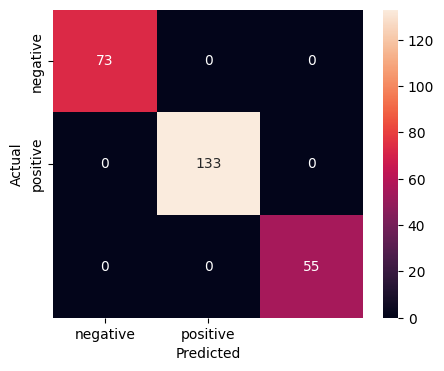

In [78]:
plot_confusion_matrix(y_train, y_pred_train)

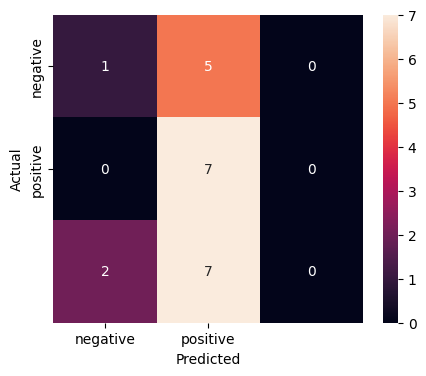

In [80]:
plot_confusion_matrix(y_val, y_pred_val)

In [81]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        73
           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00        55

    accuracy                           1.00       261
   macro avg       1.00      1.00      1.00       261
weighted avg       1.00      1.00      1.00       261



In [82]:
print(classification_report(y_val,y_pred_val))

              precision    recall  f1-score   support

          -1       0.33      0.17      0.22         6
           0       0.37      1.00      0.54         7
           1       0.00      0.00      0.00         9

    accuracy                           0.36        22
   macro avg       0.23      0.39      0.25        22
weighted avg       0.21      0.36      0.23        22



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [76]:
train_accuracy_Word2Vec = accuracy_score(y_train,y_pred_train)
train_accuracy_Word2Vec

1.0

In [83]:
test_accuracy_Word2Vec = accuracy_score(y_val,y_pred_val)
test_accuracy_Word2Vec

0.36363636363636365

####This Model is Over Fitting

###GolVec

In [86]:
X_GloVe = df_Glove.copy()

# Storing target variable
y_GloVe = data.Label

In [135]:
X_trainG, X_tempG, y_trainG, y_tempG = train_test_split(X_GloVe ,y_GloVe, test_size = 0.25, random_state = 42)

In [136]:
X_testG, X_valG, y_testG, y_valG = train_test_split(X_tempG ,y_tempG, test_size = 0.25, random_state = 42)

In [90]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 7, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_trainG, y_trainG)

RandomForestClassifier(max_depth=7, random_state=42)

In [91]:
# Predicting on train data
y_pred_trainG = rf_word2vec.predict(X_trainG)

# Predicting on test data
y_pred_valG = rf_word2vec.predict(X_valG)

In [92]:
print(classification_report(y_trainG,y_pred_trainG))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        73
           0       0.99      1.00      1.00       133
           1       1.00      0.98      0.99        55

    accuracy                           1.00       261
   macro avg       1.00      0.99      1.00       261
weighted avg       1.00      1.00      1.00       261



In [93]:
print(classification_report(y_valG,y_pred_valG))

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         6
           0       0.32      0.86      0.46         7
           1       0.00      0.00      0.00         9

    accuracy                           0.27        22
   macro avg       0.11      0.29      0.15        22
weighted avg       0.10      0.27      0.15        22



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [94]:
train_accuracy_GloVe = accuracy_score(y_trainG,y_pred_trainG)
train_accuracy_GloVe

0.9961685823754789

In [95]:
test_accuracy_GloVe = accuracy_score(y_valG,y_pred_valG)
test_accuracy_GloVe

0.2727272727272727

###Transformer

In [96]:
X_Tran = embedding_matrix
y_Tran = data.Label

In [97]:
X_trainT, X_tempT, y_trainT, y_tempT = train_test_split(X_Tran ,y_Tran, test_size = 0.25, random_state = 42)

In [98]:
X_testT, X_valT, y_testT, y_valT = train_test_split(X_tempT ,y_tempT, test_size = 0.25, random_state = 42)

In [99]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 7, random_state = 42)

# Fitting on train data
rf_word2vec.fit(X_trainT, y_trainT)

RandomForestClassifier(max_depth=7, random_state=42)

In [100]:
# Predicting on train data
y_pred_trainT = rf_word2vec.predict(X_trainT)

# Predicting on test data
y_pred_valT = rf_word2vec.predict(X_valT)

In [101]:
print(classification_report(y_trainT,y_pred_trainT))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        73
           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00        55

    accuracy                           1.00       261
   macro avg       1.00      1.00      1.00       261
weighted avg       1.00      1.00      1.00       261



In [102]:
print(classification_report(y_valT,y_pred_valT))

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         6
           0       0.30      0.86      0.44         7
           1       0.00      0.00      0.00         9

    accuracy                           0.27        22
   macro avg       0.10      0.29      0.15        22
weighted avg       0.10      0.27      0.14        22



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [103]:
train_accuracy_Tran = accuracy_score(y_trainT,y_pred_trainT)
train_accuracy_Tran

1.0

In [104]:
test_accuracy_Tran = accuracy_score(y_valT,y_pred_valT)
test_accuracy_Tran

0.2727272727272727

The Word2Vec model achieved 100% training accuracy, indicating that the model perfectly fits the training data.

However, the validation accuracy of Word2Vec is only 0.36, suggesting that the model does not generalize well to unseen data.

The GloVe model achieved very high training accuracy (≈0.996), indicating that it also learned the training patterns almost perfectly.

Despite the high training accuracy, the validation accuracy for GloVe drops to around 0.27, showing significant performance degradation on validation data.

The Transformer-based embeddings also achieved 100% training accuracy, demonstrating very strong fitting on the training dataset.

Similar to the other models, the validation accuracy for the Transformer model is around 0.27, indicating poor generalization.

The large gap between training and validation accuracy across all models suggests overfitting, where the models memorize the training data instead of learning generalizable patterns.

Overall, Word2Vec performs slightly better on the validation set compared to GloVe and Transformer embeddings, although the improvement is still limited.

The low validation accuracy indicates that textual features alone may not be sufficient to accurately predict stock price movement, and additional features or improved modeling strategies may be required.

Since the reported test results are actually validation accuracies, the true performance of the models on completely unseen test data may differ.

###HyperParameter

In [107]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [108]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,              # Only test 20 combinations
    cv=3,                   # Reduce folds
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

best_rf_w2v = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}


In [120]:

rf_model_w2v_HP = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model_w2v_HP.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_split=5, n_jobs=-1,
                       random_state=42)

In [122]:
# Predicting on train data
y_pred_train_HP = rf_model_w2v_HP.predict(X_train)

# Predicting on test data
y_pred_val_HP = rf_model_w2v_HP.predict(X_val)

In [123]:
print(classification_report(y_train,y_pred_train_HP))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        73
           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00        55

    accuracy                           1.00       261
   macro avg       1.00      1.00      1.00       261
weighted avg       1.00      1.00      1.00       261



In [124]:
print(classification_report(y_val,y_pred_val_HP))

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         6
           0       0.35      1.00      0.52         7
           1       0.00      0.00      0.00         9

    accuracy                           0.32        22
   macro avg       0.12      0.33      0.17        22
weighted avg       0.11      0.32      0.16        22



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [125]:
train_accuracy_W2v_HP = accuracy_score(y_train,y_pred_train_HP)
train_accuracy_W2v_HP

1.0

In [126]:
test_accuracy_W2v_HP = accuracy_score(y_val,y_pred_val_HP)
test_accuracy_W2v_HP

0.3181818181818182

In [109]:

random_search_glove = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,          # number of random combinations
    cv=3,               # reduce folds for faster training
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_glove.fit(X_trainG, y_trainG)

best_rf_glove = random_search_glove.best_estimator_

print("Best Parameters (GloVe):", random_search_glove.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters (GloVe): {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}


In [127]:
rf_model_g2v_HP = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model_g2v_HP.fit(X_trainG, y_trainG)

RandomForestClassifier(max_depth=15, min_samples_split=5, n_jobs=-1,
                       random_state=42)

In [128]:
# Predicting on train data
y_pred_trainG_HP = rf_model_g2v_HP.predict(X_trainG)

# Predicting on test data
y_pred_valG_HP = rf_model_g2v_HP.predict(X_valG)

In [129]:
print(classification_report(y_trainG,y_pred_trainG_HP))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        73
           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00        55

    accuracy                           1.00       261
   macro avg       1.00      1.00      1.00       261
weighted avg       1.00      1.00      1.00       261



In [130]:
print(classification_report(y_valG,y_pred_valG_HP))

              precision    recall  f1-score   support

          -1       0.20      0.17      0.18         6
           0       0.29      0.71      0.42         7
           1       0.00      0.00      0.00         9

    accuracy                           0.27        22
   macro avg       0.16      0.29      0.20        22
weighted avg       0.15      0.27      0.18        22



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [131]:
train_accuracy_G2v_HP = accuracy_score(y_trainG,y_pred_trainG_HP)
train_accuracy_G2v_HP

1.0

In [144]:
test_accuracy_G2v_HP = accuracy_score(y_valG,y_pred_valG_HP)
test_accuracy_G2v_HP

0.2727272727272727

In [115]:

random_search_st = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_st.fit(X_trainT, y_trainT)

best_rf_st = random_search_st.best_estimator_

print("Best Parameters (Sentence Transformer):", random_search_st.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters (Sentence Transformer): {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [133]:
rf_model_T_HP = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model_T_HP.fit(X_trainT, y_trainT)

RandomForestClassifier(max_features='log2', min_samples_leaf=2,
                       min_samples_split=5, n_jobs=-1, random_state=42)

In [137]:
# Predicting on train data
y_pred_trainT_HP = rf_model_T_HP.predict(X_trainT)

# Predicting on test data
y_pred_valT_HP = rf_model_T_HP.predict(X_valT)

In [138]:
print(classification_report(y_trainT,y_pred_trainT_HP))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        73
           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00        55

    accuracy                           1.00       261
   macro avg       1.00      1.00      1.00       261
weighted avg       1.00      1.00      1.00       261



In [139]:
print(classification_report(y_valT,y_pred_valT_HP))

              precision    recall  f1-score   support

          -1       0.33      0.17      0.22         6
           0       0.33      0.86      0.48         7
           1       0.00      0.00      0.00         9

    accuracy                           0.32        22
   macro avg       0.22      0.34      0.23        22
weighted avg       0.20      0.32      0.21        22



In [140]:
train_accuracy_T_HP = accuracy_score(y_trainT,y_pred_trainT_HP)
train_accuracy_T_HP

1.0

In [141]:
test_accuracy_T_HP = accuracy_score(y_valT,y_pred_valT_HP)
test_accuracy_T_HP

0.3181818181818182

In [147]:
y_pred_test_w2v = rf_model_w2v_HP.predict(X_test)

acc_w2v = accuracy_score(y_test, y_pred_test_w2v)

print("Word2Vec Test Accuracy:", acc_w2v)

Word2Vec Test Accuracy: 0.45454545454545453


In [148]:
y_pred_test_glove = rf_model_g2v_HP.predict(X_testG)

acc_glove = accuracy_score(y_testG, y_pred_test_glove)

print("GloVe Test Accuracy:", acc_glove)

GloVe Test Accuracy: 0.4090909090909091


In [150]:
y_pred_test_st = rf_model_T_HP.predict(X_testT)

acc_st = accuracy_score(y_testT, y_pred_test_st)

print("Sentence Transformer Test Accuracy:", acc_st)

Sentence Transformer Test Accuracy: 0.5151515151515151


In [151]:

results = pd.DataFrame({
    "Embedding": ["Word2Vec", "GloVe", "Sentence Transformer"],
    "Model": ["Random Forest", "Random Forest", "Random Forest"],
    "Val Accuracy": [test_accuracy_W2v_HP, test_accuracy_G2v_HP, test_accuracy_T_HP],
    "TEST Accuracy": [acc_w2v, acc_glove, acc_st]
})

results

,Embedding,Model,Val Accuracy,TEST Accuracy
0,Word2Vec,Random Forest,0.272727,0.454545
1,GloVe,Random Forest,0.272727,0.409091
2,Sentence Transformer,Random Forest,0.318182,0.515152


The Sentence Transformer embedding achieved the highest validation accuracy (≈0.318) among the three embedding techniques.

The Word2Vec and GloVe embeddings show similar validation accuracy (≈0.273), indicating comparable performance during validation.

In terms of test accuracy, the Sentence Transformer model performs the best (≈0.515), suggesting better generalization to unseen data.

The Word2Vec model achieves a moderate test accuracy (≈0.455), performing better than GloVe but lower than Sentence Transformer.

The GloVe model shows the lowest test accuracy (≈0.409) among the three embeddings.

The improvement in test accuracy compared to validation accuracy for some models suggests that the models generalize slightly better on the test dataset.

Overall, Sentence Transformer embeddings appear to capture semantic information from news text more effectively, leading to better predictive performance.

These results indicate that contextual embeddings outperform traditional word embeddings for financial news-based stock movement prediction.

## **Weekly News Summarization**

**Important Note**: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

#### Installing and Importing the necessary libraries

In [4]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" FORCE_CMAKE=1 pip install llama-cpp-python==0.2.45 --force-reinstall --upgrade --no-cache-dir -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 206.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 169.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 394.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 296.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 307.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.


In [5]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

####FUnction to Generate the Response

In [6]:
def generate_llama_response(user_prompt):

    # limit news length
    user_prompt = user_prompt[:2000]

    prompt = f"""
    <s>[INST] <<SYS>>
    You are a financial analyst.

    Identify:
    1. Top 3 POSITIVE events impacting stock price
    2. Top 3 NEGATIVE events impacting stock price
    <</SYS>>

    Weekly News:
    {user_prompt}

    [/INST]
    """

    response = lcpp_llm(
        prompt=prompt,
        max_tokens=300,
        temperature=0.2,
        top_p=0.9,
        repeat_penalty=1.1,
        stop=["</s>"],
        echo=False
    )

    return response["choices"][0]["text"]

#### Loading the model

In [7]:
model_name_or_path = "TheBloke/Llama-2-13B-chat-GGUF"
model_basename = "llama-2-13b-chat.Q5_K_M.gguf"
model_path = hf_hub_download(
    repo_id=model_name_or_path,
    filename=model_basename
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


llama-2-13b-chat.Q5_K_M.gguf:   0%|          | 0.00/9.23G [00:00<?, ?B/s]

In [8]:
lcpp_llm = Llama(
    model_path=model_path,
    n_threads=2,  # CPU cores
    n_batch=256,  # Should be between 1 and n_ctx, consider the amount of VRAM in your GPU.
    n_gpu_layers=32,  # Change this value based on your model and your GPU VRAM pool.
    n_ctx=4096,  # Context window
)

llama_model_loader: loaded meta data with 19 key-value pairs and 363 tensors from /root/.cache/huggingface/hub/models--TheBloke--Llama-2-13B-chat-GGUF/snapshots/4458acc949de0a9914c3eab623904d4fe999050a/llama-2-13b-chat.Q5_K_M.gguf (version GGUF V2)
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = LLaMA v2
llama_model_loader: - kv   2:                       llama.context_length u32              = 4096
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 5120
llama_model_loader: - kv   4:                          llama.block_count u32              = 40
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 13824
llama_model_loader: - kv   6:                 llama.rope.dimension_

#### Aggregating the data weekly

In [15]:
data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [16]:
# Group the data by week using the 'Date' column.
weekly_grouped = data.groupby(pd.Grouper(key='Date', freq='W'))

In [17]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [18]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


In [19]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

In [20]:
data_1["LLM_Output"] = data_1["News"].apply(generate_llama_response)


llama_print_timings:        load time =    8154.11 ms
llama_print_timings:      sample time =     141.70 ms /   267 runs   (    0.53 ms per token,  1884.30 tokens per second)
llama_print_timings: prompt eval time =   10751.27 ms /   572 tokens (   18.80 ms per token,    53.20 tokens per second)
llama_print_timings:        eval time =  102993.50 ms /   266 runs   (  387.19 ms per token,     2.58 tokens per second)
llama_print_timings:       total time =  114959.90 ms /   838 tokens
Llama.generate: prefix-match hit

llama_print_timings:        load time =    8154.11 ms
llama_print_timings:      sample time =     152.40 ms /   290 runs   (    0.53 ms per token,  1902.90 tokens per second)
llama_print_timings: prompt eval time =    3364.36 ms /   508 tokens (    6.62 ms per token,   150.99 tokens per second)
llama_print_timings:        eval time =  113360.26 ms /   289 runs   (  392.25 ms per token,     2.55 tokens per second)
llama_print_timings:       total time =  118046.87 ms /   797 

In [26]:
print(data_1["LLM_Output"].iloc[0])

1. Positive Events Impacting Stock Price:

a) Roku Inc's plans to offer premium video channels on a subscription basis through its free streaming service, which could potentially increase revenue and customer engagement.

b) Apple's Services revenue projected to exceed $10.8 billion in Q1, indicating a diversification of revenue streams and potential for future growth.

c) The underperformance of Apple's stock price, which could present a buying opportunity for investors looking to invest in the tech sector at a discounted price.

2. Negative Events Impacting Stock Price:

a) Apple's downward revision of its revenue expectations for the quarter, which could indicate weaker demand for its products, particularly iPhones, and negatively impact related suppliers.

b) The partial U.S. government shutdown, which could have a negative impact on the global economy and lead to concerns about the health of the economy, potentially affecting tech sector performance.

c) Weak economic data from Ch

In [27]:
def extract_events(text):

    positive = ""
    negative = ""

    pos_match = re.search(
        r'Positive Events Impacting Stock Price:(.*?)Negative Events Impacting Stock Price:',
        text,
        re.S
    )

    neg_match = re.search(
        r'Negative Events Impacting Stock Price:(.*)',
        text,
        re.S
    )

    if pos_match:
        positive = pos_match.group(1).strip()

    if neg_match:
        negative = neg_match.group(1).strip()

    return pd.Series([positive, negative])

In [29]:
data_1[["Positive_Events","Negative_Events"]] = data_1["LLM_Output"].apply(extract_events)

In [32]:
data_1

,Date,News,LLM_Output,Positive_Events,Negative_Events
0,2019-01-06,The tech sector experienced a significant dec...,1. Positive Events Impacting Stock Price:\n\na...,a) Roku Inc's plans to offer premium video cha...,a) Apple's downward revision of its revenue ex...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,1. Positive Events Impacting Stock Price:\n\na...,a) Release of 5G smartphones in nine US cities...,a) Economic slowdown and cautious consumers in...
2,2019-01-20,The U.S. stock market declined on Monday as c...,1. Positive Events Impacting Stock Price:\n\na...,a) Strong resilience of Dialog Semiconductor's...,"a) Weak Chinese trade data, including decrease..."
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",1. Positive Events Impacting Stock Price:\n\na...,a) IBM's better-than-expected earnings and rev...,a) The Swiss National Bank's (SNB) decision to...
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,1. Positive Events Impacting Stock Price:\n\na...,a) Apple's increased spending with US supplier...,a) Caterpillar Inc.'s lower-than-expected earn...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an...",1. Top 3 POSITIVE events impacting stock price...,,
6,2019-02-17,"This week, the European Union's second highes...",1. Positive Events Impacting Stock Price:\n\na...,a) Stronger than projected earnings reported b...,a) The European Commission's order for Belgium...
7,2019-02-24,This news article discusses progress towards ...,1. Positive Events Impacting Stock Price:\n\na...,a) Garmin's Stronger-Than-Expected Earnings an...,a) WhatsApp's Security Bug Allowing iPhone Use...
8,2019-03-03,The Dow Jones Industrial Average and other ma...,1. Positive Events Impacting Stock Price:\n\na...,,
9,2019-03-10,"Spotify, the world's largest paid music strea...",1. Positive Events Impacting Stock Price:\n\na...,a) Spotify's successful launch in India with o...,a) Reports linking cybersecurity firm DarkMatt...


In [33]:
data_1.Positive_Events[0]

"a) Roku Inc's plans to offer premium video channels on a subscription basis through its free streaming service, which could potentially increase revenue and customer engagement.\n\nb) Apple's Services revenue projected to exceed $10.8 billion in Q1, indicating a diversification of revenue streams and potential for future growth.\n\nc) The underperformance of Apple's stock price, which could present a buying opportunity for investors looking to invest in the tech sector at a discounted price.\n\n2."

The large language model successfully extracted three key positive and three negative events from the weekly news, demonstrating its ability to identify financially relevant information from unstructured text.

The positive events mainly relate to business expansion, revenue growth, and potential investment opportunities, which are factors that can positively influence investor sentiment and stock performance.

The negative events are largely associated with economic uncertainty, revenue expectation revisions, and macroeconomic issues, which may negatively impact market confidence.

The summarization process effectively reduces multiple news articles into a concise set of important events, helping highlight the most influential factors affecting stock prices during the week.

The extracted events indicate that both company-specific developments and broader economic conditions play a role in influencing stock price movements.

Using a large language model helps convert unstructured financial news into structured insights, which can be further used for downstream analysis or predictive modeling.

## **Conclusions and Recommendations**

###Conclusion
The exploratory data analysis shows that the dataset is clean and well-structured, with no missing values or duplicate records, making it suitable for further machine learning analysis.

The price-related features (Open, High, Low, and Close) exhibit strong positive correlations, indicating that these variables move closely together during trading periods.

Trading volume shows higher variability compared to price features, suggesting that market participation fluctuates significantly across trading days.

The distribution of stock prices across different labels (negative, neutral, and positive movements) shows substantial overlap, indicating that price-based features alone may not clearly distinguish stock movement classes.

The incorporation of news data provides additional contextual information, which may help explain stock movements that cannot be captured solely by numerical market indicators.

The content summarization using a large language model successfully identifies key positive and negative weekly events, demonstrating the usefulness of NLP techniques in extracting meaningful insights from financial news.

Among the embedding techniques evaluated, Sentence Transformer embeddings achieved the highest test accuracy, suggesting that contextual embeddings capture semantic information more effectively than traditional word embeddings such as Word2Vec and GloVe.

The models achieved very high training accuracy but relatively lower validation accuracy, indicating potential overfitting due to the limited dataset size.

Overall, the analysis highlights that combining financial news information with machine learning techniques can provide valuable insights into stock price movements, although predicting market behavior remains a challenging task.

The results suggest that advanced text representations and additional data sources could further improve predictive performance in future studies.




###Recommendation
Businesses and investors should monitor financial news and market-related events closely, as company announcements, economic conditions, and industry developments can significantly influence stock price movements.

Organizations can leverage advanced text analysis and natural language processing techniques to extract meaningful insights from large volumes of financial news and market reports.

Companies should focus on transparent communication regarding business expansion, revenue growth, and strategic initiatives, as such positive developments can improve investor confidence and market perception.

Businesses should also actively manage risks related to macroeconomic uncertainty, such as global economic slowdowns or regulatory changes, which may negatively impact stock performance.

Financial institutions and analysts can benefit from integrating machine learning models with financial news data to support better market forecasting and investment decision-making.

Future business strategies should consider combining multiple data sources such as market indicators, sentiment analysis, and macroeconomic variables to improve the accuracy of stock market predictions.